In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

warnings.filterwarnings("ignore")

# Memuat Dataset
historical = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/Wind Power/wind farm historical data.csv")
nwp = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/Wind Power/NWP.csv")

# Preprocessing awal: Pembersihan spasi dan format tanggal
historical.columns = historical.columns.str.strip()
nwp.columns = nwp.columns.str.strip()
historical['Date'] = pd.to_datetime(historical['Date'], dayfirst=True)
nwp['time'] = pd.to_datetime(nwp['time'])

# Penyesuaian nama kolom agar konsisten
historical = historical.rename(columns={'Date':'timestamp', 'Speed':'wind_speed', 'Energy':'power'})
nwp = nwp.rename(columns={'time':'timestamp', 'mod':'wind_speed_nwp', 'temp':'temperature_nwp',
                          'rh':'humidity_nwp', 'mslp':'pressure_nwp'})

# Penggabungan data (Merging) berdasarkan timestamp
data = pd.merge(historical, nwp, on='timestamp', how='inner').sort_values('timestamp').reset_index(drop=True)
data = data.ffill().dropna()

In [2]:
data_fe = data.copy()

# 1. Fitur Waktu (Siklus harian)
data_fe['hour'] = data_fe['timestamp'].dt.hour
data_fe['month'] = data_fe['timestamp'].dt.month
data_fe['hour_sin'] = np.sin(2*np.pi*data_fe['hour']/24)
data_fe['hour_cos'] = np.cos(2*np.pi*data_fe['hour']/24)

# 2. Fitur Lag (Data historis sebelumnya)
for lag in [1, 2, 3, 6, 12, 24]:
    data_fe[f'power_lag_{lag}'] = data_fe['power'].shift(lag)

# 3. Fitur Fisik (Berdasarkan Dynamic Pressure Model di Jurnal)
data_fe['temp_kelvin'] = data_fe['temperature_nwp'] + 273.15
data_fe['pressure_pascal'] = data_fe['pressure_nwp'] * 100
R_specific = 287.058 # Konstanta gas ideal untuk udara kering

# Menghitung Kerapatan Udara (Air Density)
data_fe['air_density'] = data_fe['pressure_pascal'] / (R_specific * data_fe['temp_kelvin'])

# Menghitung Theoretical Power (P = 0.5 * rho * v^3)
data_fe['physics_theoretical_power'] = 0.5 * data_fe['air_density'] * (data_fe['wind_speed_nwp']**3)

data_fe = data_fe.dropna().reset_index(drop=True)

In [3]:
import time
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit

# Menentukan fitur yang digunakan untuk prediksi
features = data_fe.drop(['timestamp', 'power', 'month'], axis=1, errors='ignore').columns
test_months = [10, 11, 12] # Pengujian pada kuartal terakhir
results_xgb = []

# Ruang lingkup parameter untuk Tuning
param_grid_xgb = {
    'n_estimators': [500, 1000],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

for month in test_months:
    train_data = data_fe[data_fe['month'] < month]
    test_data = data_fe[data_fe['month'] == month]

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(train_data[features])
    X_test = scaler.transform(test_data[features])
    y_train = train_data['power']
    y_test = test_data['power']

    # --- Model 1: XGBoost Baseline (Default) ---
    start_time = time.time()
    model_def = XGBRegressor(objective='reg:squarederror', random_state=42)
    model_def.fit(X_train, y_train)
    pred_def = model_def.predict(X_test)
    waktu_def = time.time() - start_time

    results_xgb.append({
        'Month': month, 'Model': 'XGBoost Baseline',
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_def)),
        'MAE': mean_absolute_error(y_test, pred_def),
        'R2': r2_score(y_test, pred_def),
        'Waktu_Komputasi_Detik': round(waktu_def, 2)
    })

    # Inisialisasi TimeSeriesSplit untuk validasi silang
    tscv = TimeSeriesSplit(n_splits=3)

    # --- Model 2: XGBoost + RandomizedSearchCV + TimeSeriesSplit ---
    start_time = time.time()
    random_search = RandomizedSearchCV(
        estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
        param_distributions=param_grid_xgb,
        n_iter=5, # Mencoba 5 kombinasi acak untuk menghemat waktu
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    pred_random = random_search.best_estimator_.predict(X_test)
    waktu_random = time.time() - start_time

    results_xgb.append({
        'Month': month, 'Model': 'XGBoost (Random Search)',
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_random)),
        'MAE': mean_absolute_error(y_test, pred_random),
        'R2': r2_score(y_test, pred_random),
        'Waktu_Komputasi_Detik': round(waktu_random, 2)
    })

    # --- Model 3: XGBoost + GridSearchCV + TimeSeriesSplit ---
    start_time = time.time()
    grid_search = GridSearchCV(
        estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
        param_grid=param_grid_xgb,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    pred_grid = grid_search.best_estimator_.predict(X_test)
    waktu_grid = time.time() - start_time

    results_xgb.append({
        'Month': month, 'Model': 'XGBoost (Grid Search)',
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_grid)),
        'MAE': mean_absolute_error(y_test, pred_grid),
        'R2': r2_score(y_test, pred_grid),
        'Waktu_Komputasi_Detik': round(waktu_grid, 2)
    })

    print(f"Selesai mengevaluasi Bulan {month}.")
    print(f"-> Parameter Terbaik Grid Search: {grid_search.best_params_}")

Selesai mengevaluasi Bulan 10.
-> Parameter Terbaik Grid Search: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Selesai mengevaluasi Bulan 11.
-> Parameter Terbaik Grid Search: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Selesai mengevaluasi Bulan 12.
-> Parameter Terbaik Grid Search: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}



=== Performa Rata-rata Model ===
                  Model       RMSE       MAE       R2  Waktu_Komputasi_Detik
  XGBoost (Grid Search) 135.672523 89.499750 0.907848              98.196667
XGBoost (Random Search) 135.591730 87.710535 0.907611              32.250000
       XGBoost Baseline 144.040381 93.516474 0.896777               0.786667


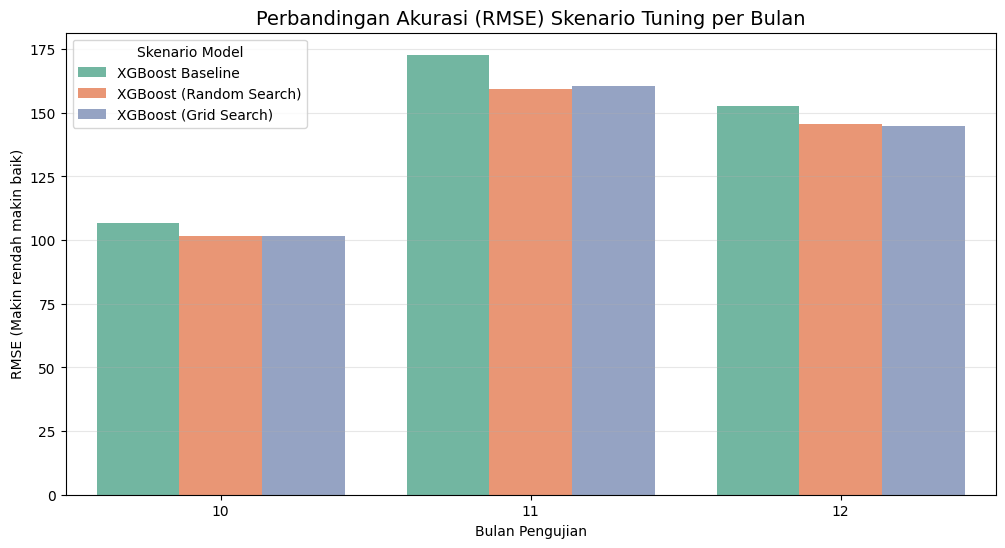

In [5]:
# Menampilkan DataFrame performa model
xgb_df = pd.DataFrame(results_xgb)

print("\n=== Performa Rata-rata Model ===")
# Rata-rata dihitung dari pengujian bulan 10, 11, dan 12
avg_performance = xgb_df.groupby('Model')[['RMSE', 'MAE', 'R2', 'Waktu_Komputasi_Detik']].mean().reset_index()
print(avg_performance.to_string(index=False))

# Visualisasi RMSE per Bulan
plt.figure(figsize=(12, 6))
sns.barplot(data=xgb_df, x='Month', y='RMSE', hue='Model', palette='Set2')
plt.title('Perbandingan Akurasi (RMSE) Skenario Tuning per Bulan', fontsize=14)
plt.ylabel('RMSE (Makin rendah makin baik)')
plt.xlabel('Bulan Pengujian')
plt.legend(title='Skenario Model')
plt.grid(axis='y', alpha=0.3)
plt.show()